In [1]:
import sys, os
root = "/workspace"
if root not in sys.path:
    sys.path.insert(0, root)

import cv2
import matplotlib.pyplot as plt
from VideoStreamer.streamer_api import CCTVStreamer
%pip -q install ipympl ipywidgets
%matplotlib widget

import matplotlib
print("backend:", matplotlib.get_backend())  # widget/nbagg 계열이면 OK


Note: you may need to restart the kernel to use updated packages.
backend: module://ipympl.backend_nbagg


In [ ]:
# %pip -q install ipympl
# %matplotlib widget

import cv2, numpy as np, matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

def pixel_picker_stream(
    frame_getter,               # callable → BGR np.ndarray 한 장 반환 (예: lambda: temp.capture())
    title="(x,y) Pixel Picker!",
    interval_sec=5.0,           # ✅ 5초마다 새 프레임
    scale=1.0,
    marker_size=10,
    show_axes=True,
    keep_ticks_pad=0.05,
    annotate=True,
    close_previous=True
):
    # 1) 최초 프레임
    first_bgr = frame_getter()
    if first_bgr is None or first_bgr.size == 0:
        raise RuntimeError("frame_getter() returned empty frame")
    h, w = first_bgr.shape[:2]
    first_rgb = cv2.cvtColor(first_bgr, cv2.COLOR_BGR2RGB)

    if close_previous:
        plt.close('all')

    # 2) Figure 준비 (이미지 크기에 딱 맞춤)
    dpi = 100
    fig_w, fig_h = (w/dpi)*scale, (h/dpi)*scale
    fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=dpi)
    im = ax.imshow(first_rgb, aspect="equal", zorder=0)
    ax.set_title(title)
    ax.set_xlim(-0.5, w-0.5)
    ax.set_ylim(h-0.5, -0.5)

    if show_axes:
        ax.axis("on")
        pad = float(keep_ticks_pad)
        plt.subplots_adjust(left=pad, right=1-pad, bottom=pad, top=1-pad)
    else:
        ax.axis("off")
        ax.set_position([0, 0, 1, 1])
        plt.subplots_adjust(left=0, right=1, bottom=0, top=1)

    try:
        fig.tight_layout(pad=0)
    except Exception:
        pass

    try:
        fig.canvas.layout.width  = f"{int(w*scale)}px"
        fig.canvas.layout.height = f"{int(h*scale)}px"
        if hasattr(fig.canvas, "toolbar_visible"): fig.canvas.toolbar_visible = False
        if hasattr(fig.canvas, "header_visible"):  fig.canvas.header_visible  = False
        if hasattr(fig.canvas, "footer_visible"):  fig.canvas.footer_visible  = False
    except Exception:
        pass

    # 3) 클릭 마커(유지)
    clicks, labels = [], []
    scat = ax.scatter([], [], s=marker_size, c="deepskyblue",
                      edgecolors="white", linewidths=1.5, zorder=5)

    def redraw_markers():
        scat.set_offsets(np.asarray(clicks) if clicks else np.empty((0, 2)))
        fig.canvas.draw_idle()

    def on_click(event):
        if event.inaxes is not ax or event.xdata is None or event.ydata is None:
            return
        x, y = int(round(event.xdata)), int(round(event.ydata))
        clicks.append((x, y))
        print(f"clicked: (x={x}, y={y})")
        if annotate:
            labels.append(ax.text(
                x+6, y-6, f"({x},{y})",
                color="yellow", fontsize=8, zorder=6,
                bbox=dict(facecolor="black", alpha=0.45, pad=1)
            ))
        redraw_markers()

    fig.canvas.mpl_connect('button_press_event', on_click)

    # 4) 스트리밍 업데이트(프레임만 교체, 마커는 그대로)
    def _update(_):
        bgr = frame_getter()
        if bgr is None or bgr.size == 0:
            return
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        im.set_data(rgb)
        # 축/스캐터/라벨은 그대로 둠
        fig.canvas.draw_idle()

    anim = FuncAnimation(fig, _update, interval=int(interval_sec*1000), blit=False)
    # 참조 유지(가비지 컬렉션 방지)
    fig._anim_ref = anim

    # 간단 컨트롤 제공
    class Controls:
        def pause(self):  anim.event_source.stop()
        def resume(self): anim.event_source.start()
        def stop(self):   anim.event_source.stop()

    return fig, ax, Controls()


<ipython-input-2-4ffe7b841834>:95: UserWarning: frames=None which we can infer the length of, did not pass an explicit *save_count* and passed cache_frame_data=True.  To avoid a possibly unbounded cache, frame data caching has been disabled. To suppress this warning either pass `cache_frame_data=False` or `save_count=MAX_FRAMES`.
  anim = FuncAnimation(fig, _update, interval=int(interval_sec*1000), blit=False)


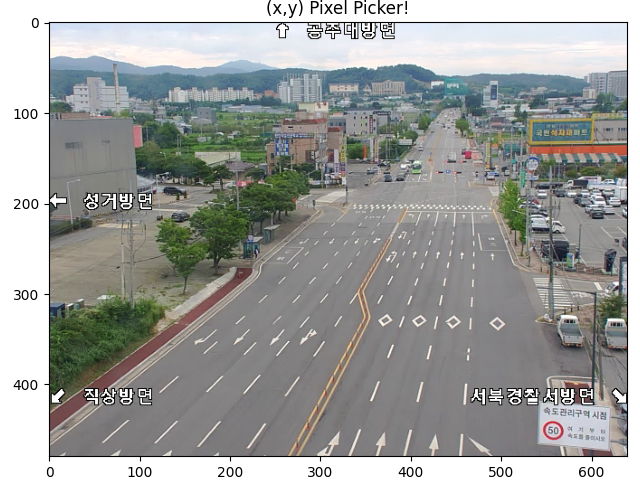

In [3]:
# 준비 그대로
cctv_url = "rtsp://210.99.70.120:1935/live/cctv001.stream"
temp = CCTVStreamer(url=cctv_url, max_width=640).start()
temp.wait_ready(timeout=5.0)

def get_frame():
    return temp.capture()

fig, ax, ctrl = pixel_picker_stream(
    frame_getter=get_frame,  # 또는 lambda: temp.capture()
    interval_sec=5.0,        # 5초마다 프레임만 갱신 (마커/라벨은 유지)
    scale=1.0,
    show_axes=True,
    annotate=True
)

# 필요시 컨트롤
# ctrl.pause()
# ctrl.resume()
# ctrl.stop()


In [4]:
#temp.stop()